**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 须遵守与协作相同的政策。与其他协作者一样，每位学生都必须独立于交互输出撰写解答，并在提交内容中注明协作的性质。使用生成式 AI 工具完成作业中的实质性部分不符合本作业的精神，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。\n

In [28]:
# Configure paths for the local assignment3 directory.
from pathlib import Path
import os
import sys

ASSIGNMENT_ROOT = Path.cwd().resolve()
if not (ASSIGNMENT_ROOT / 'cs231n').is_dir():
    ASSIGNMENT_ROOT = ASSIGNMENT_ROOT / 'assignment' / 'assignment3'
assert (ASSIGNMENT_ROOT / 'cs231n').is_dir(), (
    f'Cannot find assignment3/cs231n from {Path.cwd().resolve()}'
)
os.chdir(ASSIGNMENT_ROOT)
if str(ASSIGNMENT_ROOT) not in sys.path:
    sys.path.insert(0, str(ASSIGNMENT_ROOT))
print(f'Using assignment directory: {ASSIGNMENT_ROOT}')

Using assignment directory: C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment3


In [29]:
# The existing local COCO captioning dataset is used from:
# cs231n/datasets/coco_captioning
COCO_ROOT = ASSIGNMENT_ROOT / 'cs231n' / 'datasets' / 'coco_captioning'
assert COCO_ROOT.is_dir(), f'COCO dataset not found: {COCO_ROOT}'
print(f'Using COCO dataset: {COCO_ROOT}')

Using COCO dataset: C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment3\cs231n\datasets\coco_captioning


# 最先进的预训练图像模型

在上一个练习中，你学习了 [SimCLR](https://arxiv.org/abs/2002.05709)，并了解了如何利用对比式自监督学习得到有意义的图像表征。在本 Notebook 中，我们将探索另外两个较新的模型。它们同样旨在学习高质量的视觉表征，并已在多种下游任务上展现出强大且稳健的性能。

首先，我们将研究 [CLIP](https://github.com/openai/CLIP) 模型。与 SimCLR 类似，CLIP 使用对比学习目标；但它对比的不是同一图像的两个增强视图，而是文本和图像两种不同模态。为了训练 CLIP，OpenAI 从互联网收集了约 4 亿个图像—文本对，其中包括维基百科内容和图像替代文本等来源。所得模型能够学习丰富的高级图像特征，并在许多视觉基准上取得了令人瞩目的零样本性能。

接下来，我们将探索 [DINO](https://github.com/facebookresearch/dino)。这是一种面向视觉任务的自监督学习方法，在采用多裁剪增强策略的自蒸馏框架中应用对比学习。作者证明，DINO 的 ViT 所学习的特征粒度细、语义丰富，并明确包含图像语义分割相关的信息。

# CLIP

如上所述，CLIP 的训练目标建立在对比学习原理之上，同时使用文本和图像。回顾 SimCLR Notebook 中的这段话：
>对比损失的目标是最大化最终向量 **$z_i = g(h_i)$** 与 **$z_j = g(h_j)$** 之间的一致性。

类似地，CLIP 的训练目标也是最大化两个向量之间的一致性。不过，由于这些向量来自不同模态，CLIP 使用两个独立的编码器：基于 Transformer 的文本编码器，以及基于视觉 Transformer（ViT）的图像编码器。请注意，某些规模较小、效率更高的 CLIP 版本会使用 ResNet 代替 ViT 作为图像编码器。

运行下面的单元格，以可视化 CLIP 的训练和推理流程。

在预训练阶段，每个批次都包含多张图像及其对应的描述文本。每张图像由图像编码器独立处理——通常是视觉 Transformer（ViT）或卷积神经网络（ConvNet）等视觉模型——并产生图像嵌入 $I_n$。同样，每条描述文本由文本编码器独立处理，产生对应的文本嵌入 $T_n$。随后，我们计算所有图像—文本组合之间的两两相似度，也就是让每张图像与每条描述进行比较，反之亦然。训练目标是最大化所得相似度矩阵对角线上的分数，即匹配图像—描述对 $(I_n, T_n)$ 的分数。通过反向传播，模型学会为真实匹配分配比错误匹配更高的相似度。

借助这一设置，CLIP 能够在共享潜在空间中表示图像和文本。在这个空间中，语义概念以不依赖模态的方式编码，因此可以在视觉输入和文本输入之间进行有意义的跨模态比较。

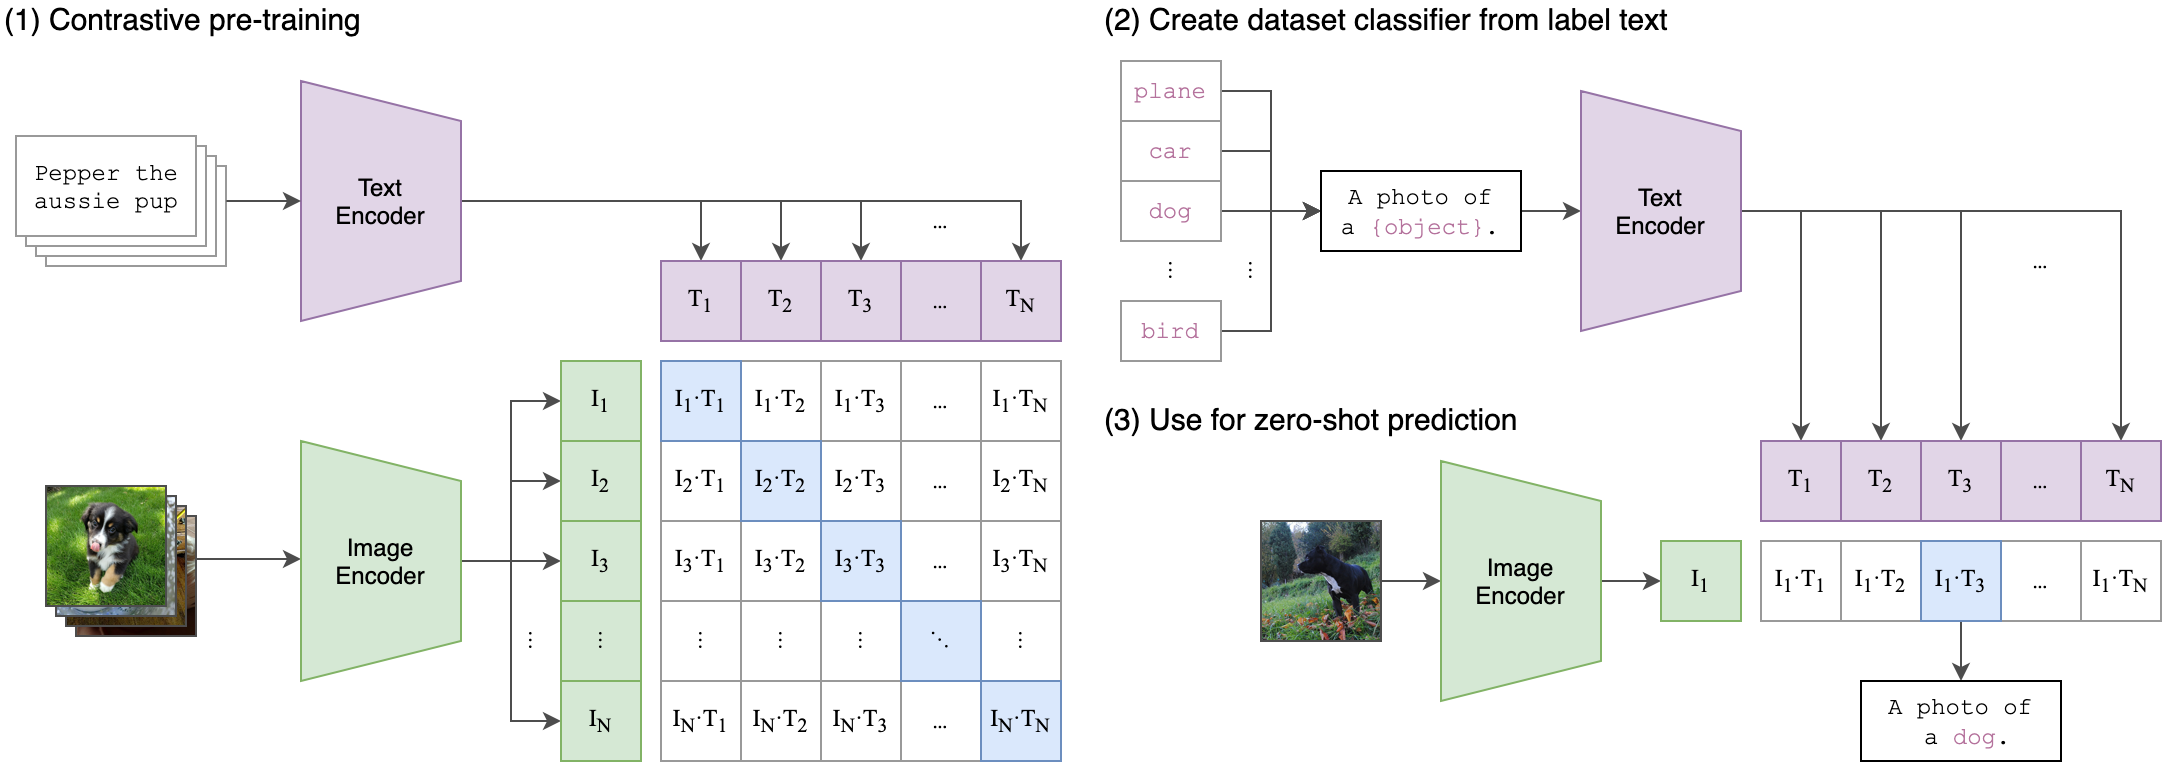

In [30]:
from IPython.display import Image as NotebookImage
NotebookImage(filename=str(ASSIGNMENT_ROOT / 'CLIP.png'))

**随堂问题 1** —

为什么 CLIP 的学习效果依赖批量大小？如果批量大小固定，我们可以采用什么策略来学习丰富的图像特征？

$\color{blue}{\textit Your Answer:}$

# 加载 COCO 数据集

我们将使用你训练 RNN 图像描述模型时用过的同一描述数据集。不过，这次我们不生成描述，而是尝试将每张图像与正确的描述进行匹配。

In [31]:
import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import clip
import torch
from tqdm.auto import tqdm

from PIL import Image
from cs231n.clip_dino import *

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-10, np.abs(x) + np.abs(y))))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

In [33]:
# Load COCO data from disk into a dictionary.
# this is the same dataset you used for the RNN captioning notebook :)
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment3\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


In [34]:
# we're just using the loaded captions from COCO, so we need to decode them and get rid of the special tokens.
decoded_captions= []
for caption in data['val_captions']:
  caption = decode_captions(caption, data['idx_to_word'])\
    .replace('<START>', '')\
    .replace('<END>', '')\
    .replace('<UNK>', '')\
    .strip()
  decoded_captions.append(caption)

In [35]:
# lets get 10 examples
mask = np.array([135428, 122586, 122814, 133173, 176639, 163828,  98169,   6931,
        19488, 175760])
first_captions = [decoded_captions[elem] for elem in mask]

img_idxs = data['val_image_idxs'][mask]       # the images the captions refer to
first_images   = [image_from_url(data['val_urls'][j]) for j in img_idxs]

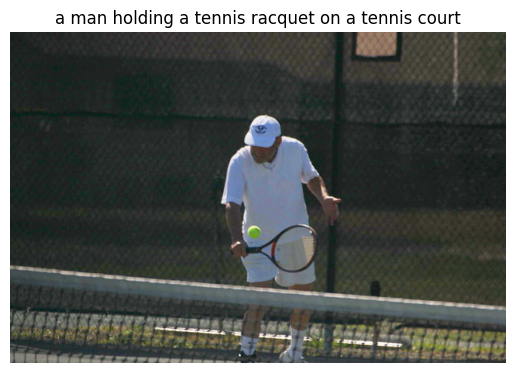

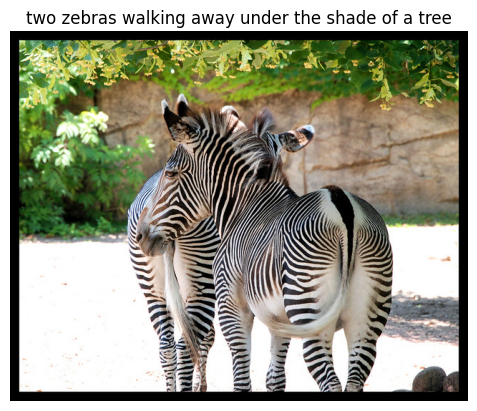

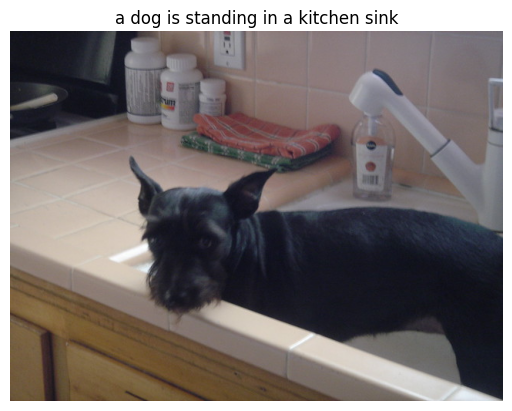

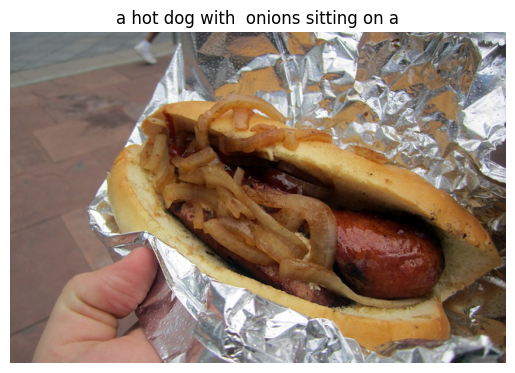

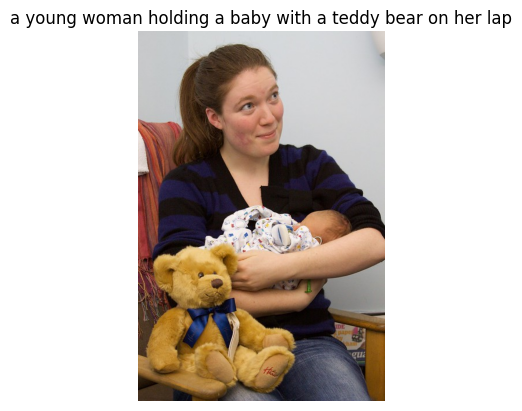

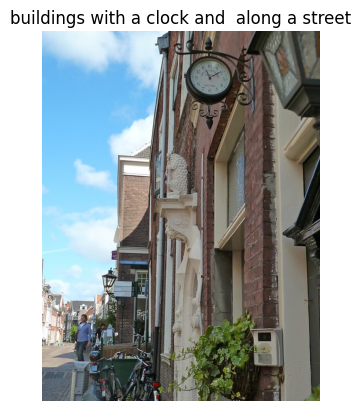

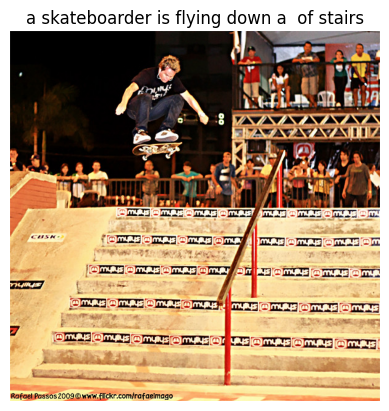

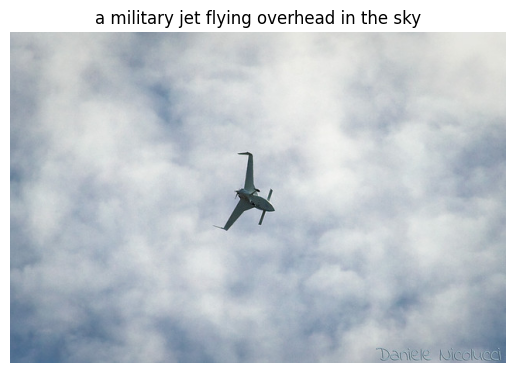

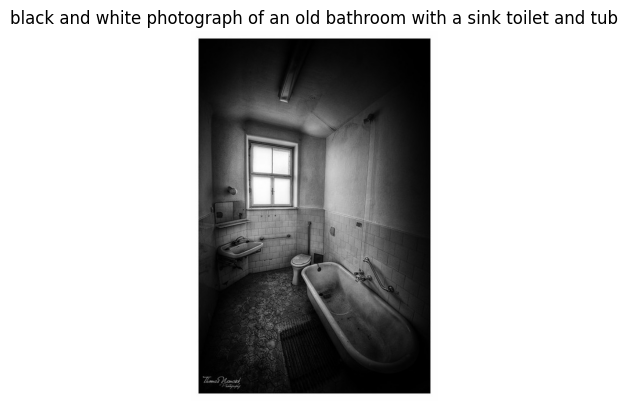

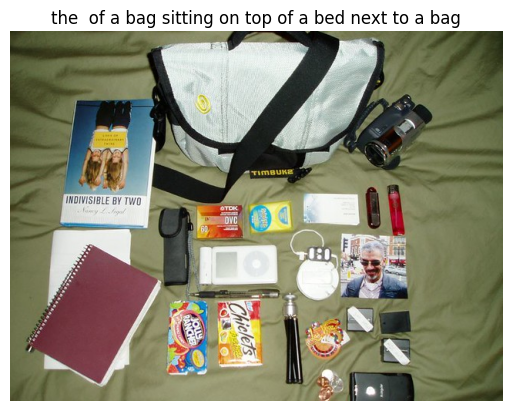

In [36]:
for i, (caption, image) in enumerate(zip(first_captions, first_images)):
    plt.imshow(image)
    plt.axis('off')
    caption_str = caption
    plt.title(caption_str)
    plt.show()

# 运行 CLIP 模型

首先，我们使用预训练 CLIP 模型分别从文本和图像中提取特征。

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

In [38]:
# You can check the model layers by printing the model.
# CLIP's model code is available at https://github.com/openai/CLIP/tree/main/clip
# print(clip_model)

In [39]:
# First, we encode the captions into vectors in the shared embedding space.
# Since we're using a Transformer as the text encoder, we need to tokenize the text first.
text_tokens = clip.tokenize(first_captions).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)

# Sanity check, print the shape
print(text_features.shape)

# Note: For your implementations, use the above clip_model.encode_text() function. Avoid using clip_model.forward().

torch.Size([10, 512])


In [40]:
# Then, we encode the images into the same embedding space.
processed_images = [
    clip_preprocess(Image.fromarray(img)).unsqueeze(0)
    for img in first_images
]
images_tensor = torch.cat(processed_images, dim=0).to(device)

with torch.no_grad():
    image_features = clip_model.encode_image(images_tensor)

# sanity check, print the shape
print(image_features.shape)

# Note: For your implementations, use the above clip_model.encode_image() function. Avoid using clip_model.forward().

torch.Size([10, 512])


打开 `cs231n/clip_dino.py` 并实现 `get_similarity_no_loop`，计算文本特征与图像特征之间的相似度分数。请在下方测试你的实现；相对误差应小于 1e-5。

In [41]:
from cs231n.clip_dino import get_similarity_no_loop
torch.manual_seed(231)
np.random.seed(231)
M, N, D = 5, 6, 10

test_text_features = torch.randn(N, D)
test_image_features = torch.randn(M, D)
out = get_similarity_no_loop(test_text_features, test_image_features)

expected_out = np.array([
    [ 0.1867811 , -0.23494351,  0.44155994, -0.18950461,  0.00100103],
    [ 0.17905031, -0.25469488, -0.64330417,  0.25097957, -0.09327742],
    [-0.4407011 , -0.4365381 ,  0.32857686, -0.3765278 ,  0.01049389],
    [ 0.24815483,  0.42157224, -0.08459304,  0.14132318, -0.26935193],
    [ 0.02309848, -0.01441101,  0.5469337 ,  0.6018773 ,  0.21581158],
    [ 0.41579214, -0.014449  , -0.7242257 ,  0.39348006,  0.0822239 ],
]).astype(np.float32)

print("relative error: ", rel_error(out.numpy(), expected_out))

relative error:  1.4769752e-05


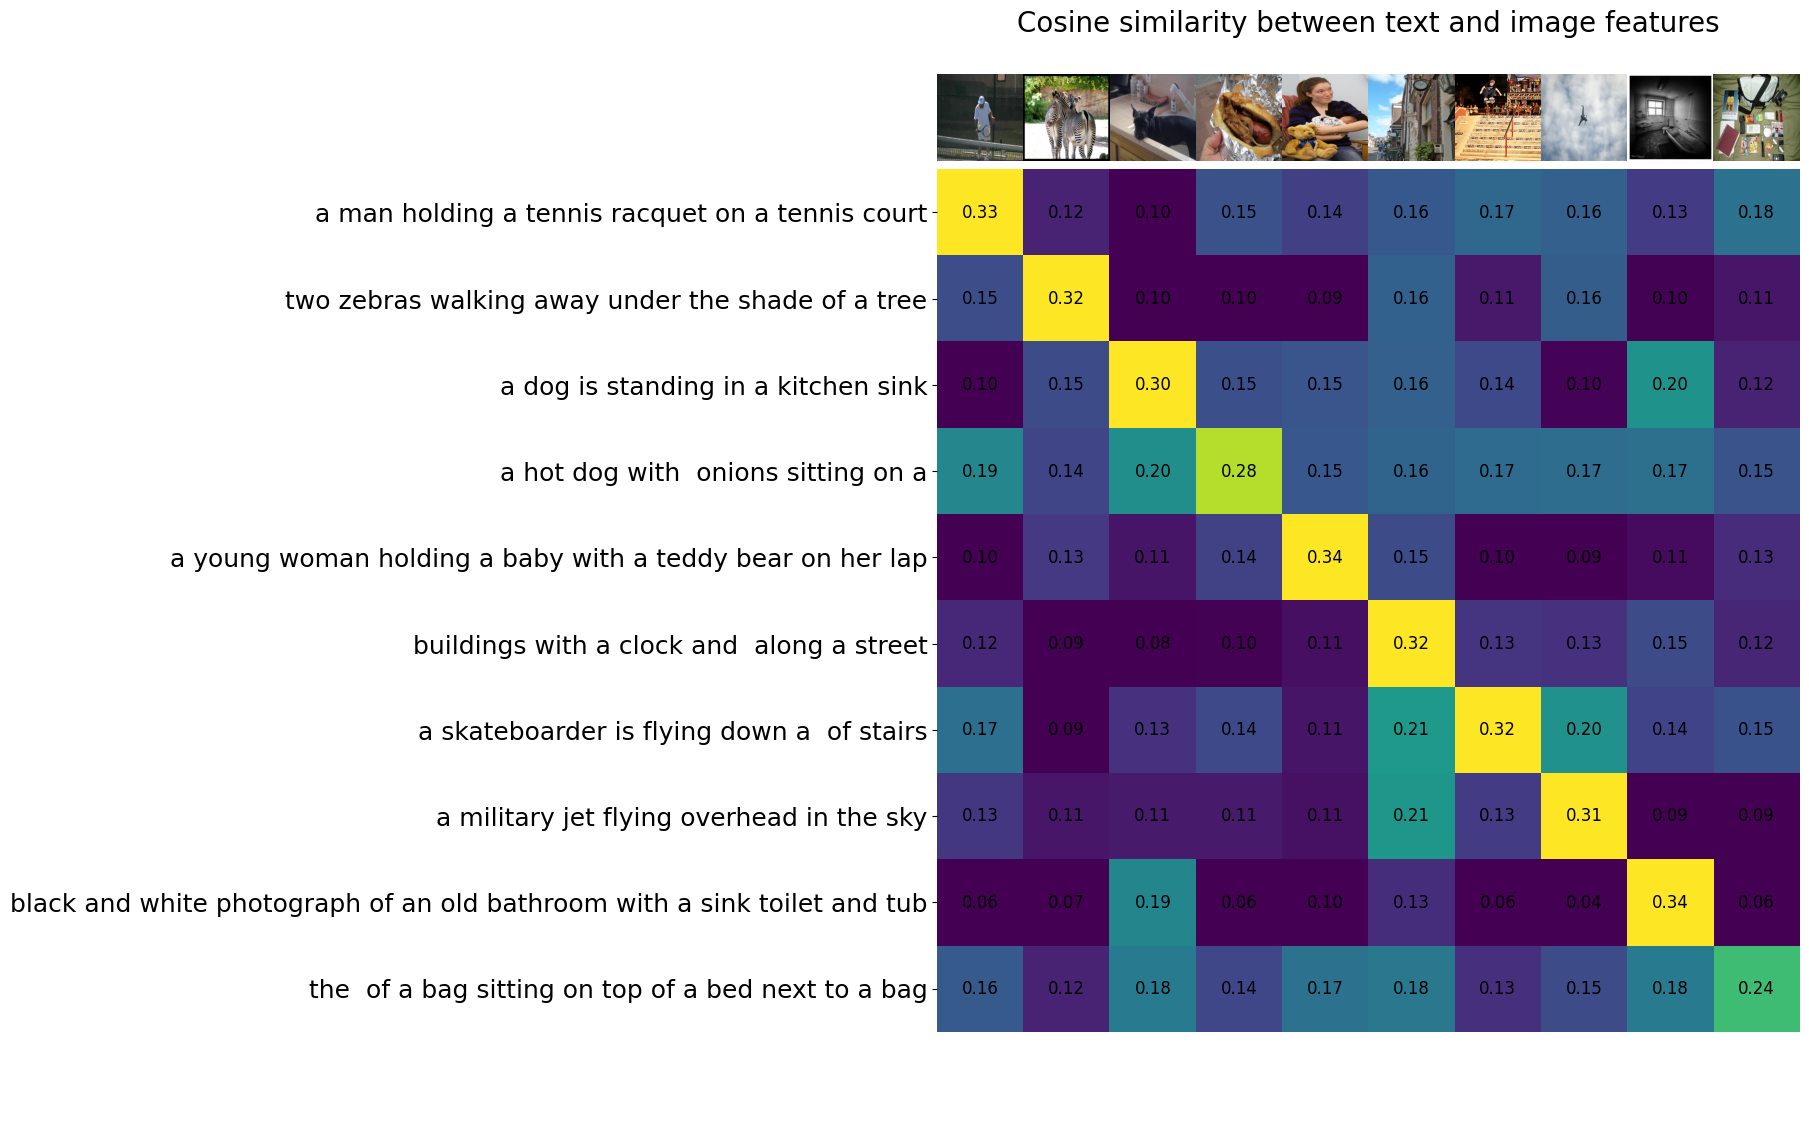

In [42]:
# Let's visualize the similarities between our batch of images and their captions.

similarities = get_similarity_no_loop(text_features, image_features).cpu().detach().numpy()

plt.figure(figsize=(20, 14))
plt.imshow(similarities, vmin=0.1, vmax=0.3)
plt.yticks(range(len(text_features)), first_captions, fontsize=18)
plt.xticks([])
for i, image in enumerate(first_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarities.shape[1]):
    for y in range(similarities.shape[0]):
        plt.text(x, y, f"{similarities[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, len(image_features) - 0.5])
plt.ylim([len(text_features) + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)
plt.show()

# 零样本分类器

在上面可以看到，匹配的图像—描述对具有很高的相似度。我们可以利用这一性质设计一种不需要任何标注数据的图像分类器，即零样本分类器。每个类别都可以用恰当的自然语言描述来表示；对于任意输入图像，分类器会在 CLIP 嵌入空间中找出与该图像相似度最高的描述，并将图像归入对应类别。

在 `cs231n/clip_dino.py` 中实现 `clip_zero_shot_classifier`，并在下方进行测试。你应该会看到以下预测结果：

['a person', 'an animal', 'an animal', 'food', 'a person', 'a landscape', 'other', 'other', 'other', 'a person']

In [43]:
from cs231n.clip_dino import clip_zero_shot_classifier

classes = ["a person", "an animal", "food", "a landscape", "other"]

pred_classes = clip_zero_shot_classifier(
    clip_model, clip_preprocess, first_images, classes, device)

print(pred_classes)

['a person', 'an animal', 'an animal', 'food', 'a person', 'a landscape', 'other', 'an animal', 'other', 'a person']


运行下面的单元格以可视化预测结果。可以看到，CLIP 提供了一种简单直接的方法，可以针对任意类别体系执行效果尚可的零样本分类。

CLIP 是第一个在不使用任何 ImageNet 图像或标签的情况下，性能超过 ImageNet 标准监督训练的模型（CLIP 原论文中还包含许多类似的有趣实验和分析）。

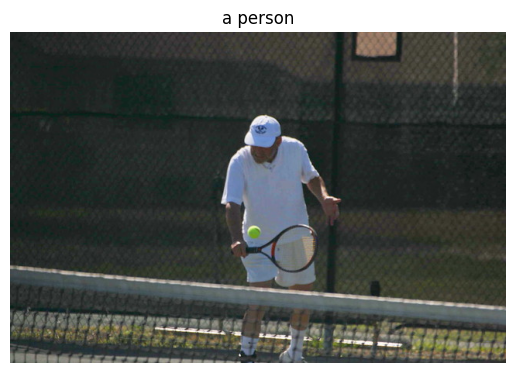

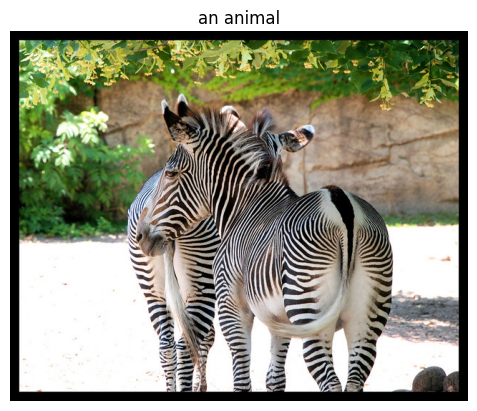

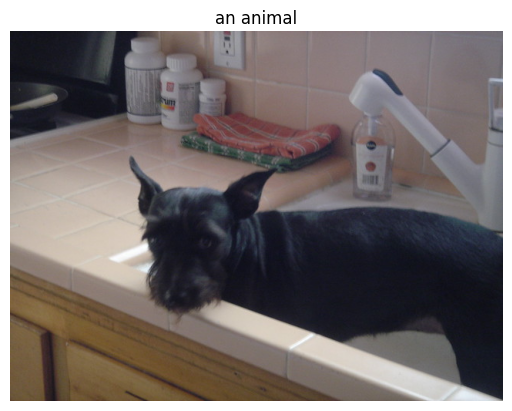

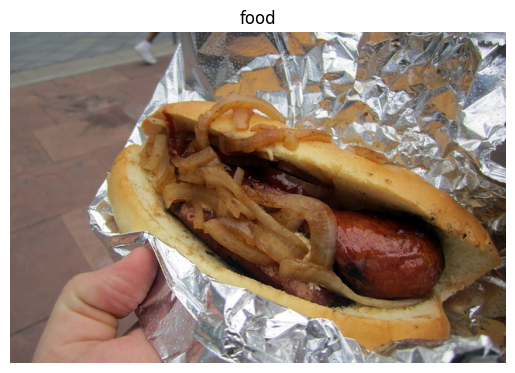

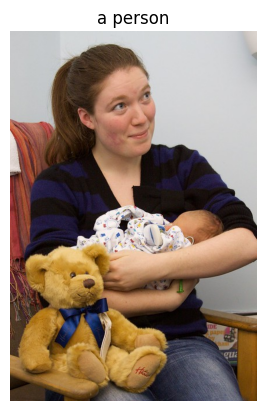

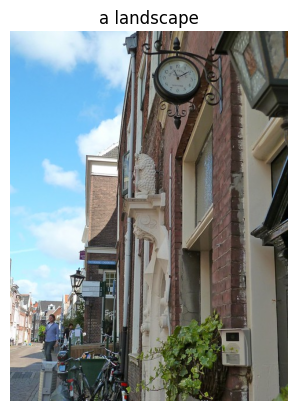

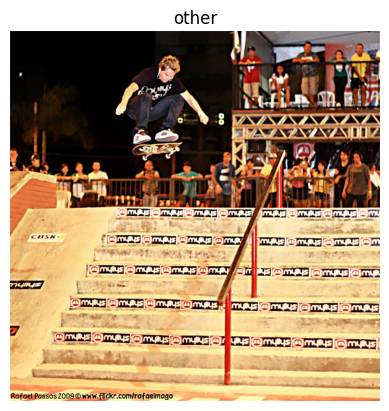

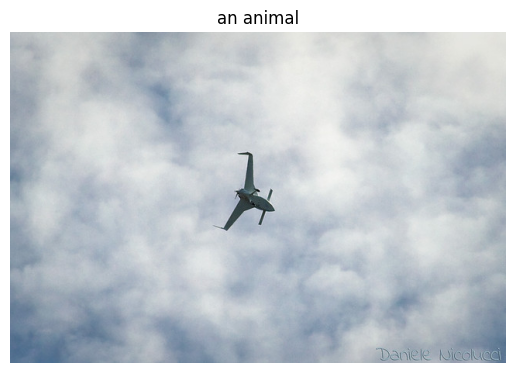

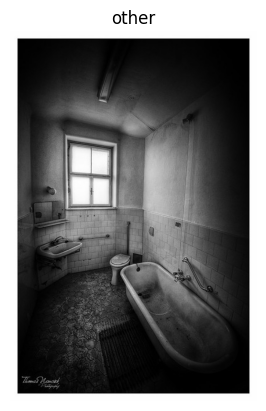

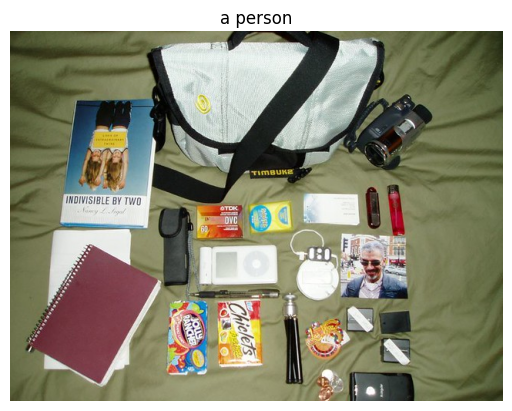

In [48]:
# Visualize the zero shot predictions
for i, (pred_class, image) in enumerate(zip(pred_classes, first_images)):
    plt.imshow(image)
    plt.axis('off')
    plt.title(pred_class)
    plt.show()

# 使用 CLIP 进行图像检索

正如我们使用 CLIP 为每张图像检索匹配的类别名称一样，也可以根据文本输入检索匹配的图像，即语义图像检索。请在 `cs231n/clip_dino.py` 中实现 `CLIPImageRetriever`，并运行下面两个单元格进行测试。注释中给出了每个查询预期排名前 2 的输出。

In [51]:
from cs231n.clip_dino import CLIPImageRetriever
clip_retriever = CLIPImageRetriever(clip_model, clip_preprocess, first_images, device)

In [52]:
query = "sports"  # tennis, skateboard
# query = "black and white"  # bathroom, zerbas
img_indices = clip_retriever.retrieve(query)

for img_index in img_indices:
    plt.imshow(first_images[img_index])
    plt.axis('off')
    plt.show()

**随堂问题 2** —

CLIP 使用对比损失，在共享潜在空间中对齐图像与文本表征。你会如何将这一思想扩展到两种以上的模态？

$\color{blue}{\textit Your Answer:}$

# DINO

如前所述，使用普通对比学习方法训练的模型（如 SimCLR 和 CLIP）需要非常大的批量，因此计算成本高且不易使用。后续工作（如 [BYOL](https://arxiv.org/abs/2006.07733)）提出了一种替代方法：使用学生—教师框架，避免依赖大量负样本。该方法取得了出人意料的良好效果，后来又被 [DINO](https://arxiv.org/abs/2104.14294) 采用。

与 SimCLR 类似，DINO 的训练目标也是最大化从同一图像不同视图得到的两个向量之间的一致性。但与 SimCLR 不同，DINO 使用两个训练方式不同的独立编码器。学生网络通过反向传播更新，以匹配教师网络的输出。教师网络不通过反向传播更新，而是使用学生权重的指数移动平均（EMA）来更新权重。这意味着教师模型变化得更慢，能够为学生提供稳定的学习目标。

运行下面的单元格，以可视化 DINO 的训练流程。

In [ ]:
from IPython.display import Image as NotebookImage
NotebookImage(filename=str(ASSIGNMENT_ROOT / 'dino.gif'))

In [ ]:
# first let's get rid of the CLIP model that's currently using memory
del clip_model
# Uncomment the following if you are using GPU runtime
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

In [ ]:
# Load smallest dino model. ViT-S/8. Here ViT-S has ~22M parameters and
# works on 8x8 patches.
dino_model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
dino_model.eval().to(device)


In [ ]:
# the image we will be playing around with
sample_image = Image.fromarray(first_images[0]).convert("RGB")
sample_image

# DINO 注意力图

由于加载的 DINO 检查点基于 ViT 架构，我们可以可视化每个注意力头所关注的区域。下面的代码会生成热力图，展示最后一层各个注意力头中，[CLS] 标记关注原始图像的哪些图块。虽然该模型使用自监督目标训练，从未被明确要求识别图像中的“结构”，但它仍然……

你观察到什么规律了吗？

In [ ]:
# Preprocess
from torchvision import transforms as T
transform = T.Compose([
    T.Resize((480, 480)),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
img_tensor = transform(sample_image)
w, h = img_tensor.shape[1:]
img_tensor = img_tensor[None].to(device)

# Extract attention
with torch.no_grad():
    attn = dino_model.get_last_selfattention(img_tensor)[0, :, 0, 1:]
nh, tokens = attn.shape
w_feat, h_feat = w // 8, h // 8
attn = attn.reshape(nh, w_feat, h_feat)
attn = torch.nn.functional.interpolate(attn.unsqueeze(0), scale_factor=8, mode="nearest")[0].cpu().numpy()

# Plot attention heads
fig, axes = plt.subplots(1, nh, figsize=(3 * nh, 3))
for i in range(nh):
    ax = axes[i] if nh > 1 else axes
    ax.imshow(attn[i], cmap='inferno')
    ax.axis('off')
plt.show()

In [ ]:
# Extract patch token features and discard [CLS] token.
with torch.no_grad():
    all_tokens = dino_model.get_intermediate_layers(img_tensor, n=1)[0]  # (1, 1+N, D)
    patch_tokens = all_tokens[:, 1:, :]  # (N, D)

print(img_tensor.shape)
print(all_tokens.shape)
print(patch_tokens.shape)

**随堂问题 3**

上面打印出的张量形状是如何得到的？请解释你的答案。

$\color{blue}{\textit Your Answer:}$

# DINO 特征

为了理解模型在每个图块中编码了什么，我们可以可视化各个图块标记的内容。由于这些嵌入维度很高，难以直接解释，我们将使用 PCA 找出特征空间中方差最大的方向。

在下一个单元格中，我们会可视化特征空间中方差最大的三个主方向，从而揭示图块嵌入所捕获的主要结构。

In [ ]:
from sklearn.decomposition import PCA

np.random.seed(231)

# PCA
pca = PCA(n_components=3)
patch_pca = pca.fit_transform(patch_tokens.cpu().numpy()[0])

# Normalize PCA components to [0, 1] for RGB display
patch_rgb = (patch_pca - patch_pca.min(0)) / (patch_pca.max(0) - patch_pca.min(0))

# Reshape to image grid (60x60, 3)
patch_rgb_img = patch_rgb.reshape(60, 60, 3)

# Show as image
plt.figure(figsize=(6, 6))
plt.imshow(patch_rgb_img)
plt.axis('off')
plt.title("Patch Embeddings (PCA → RGB)")
plt.show()

**随堂问题 4** —

你在上面的可视化中看到了什么结构？如果一个区域始终呈现某种特定颜色，这意味着什么？如果两个区域的颜色明显不同，又意味着什么？请记住，PCA 展示的是所有图块在特征空间中方差最大的方向；一个图块的颜色反映其独特的特征内容。

$\color{blue}{\textit Your Answer:}$

# 基于 DINO 特征的简单分割模型

在上一节中，我们看到 DINO 特征能提供出人意料的良好分割线索。现在，让我们在 [DAVIS 数据集](https://davischallenge.org) 上训练一个简单的分割模型，检验这一想法。DAVIS（Densely Annotated VIdeo Segmentation，稠密标注视频分割）数据集为视频对象分割任务创建，提供视频中对象逐帧、逐像素的标注。在本实验中，我们只使用一段视频某一帧的标注来训练模型，并观察它在同一视频其余帧上的表现。

我们的模型会刻意保持精简：按图块提取 DINO 特征，并仅使用这一帧带标注图像中的图块来训练轻量级逐图块分类器。通常，你会在完整数据集上训练，并在包含不同视频的独立验证集上评估。但这里我们要测试 DINO 特征的单样本能力。

In [ ]:
from cs231n.clip_dino import DavisDataset

# A helper class to work with DAVIS dataset.
# It may take ~5 minutes on the first run of this cell to download the dataset.
davis_ds = DavisDataset()

# Get a specific test video. Do NOT change this for submission.
frames, masks = davis_ds.get_sample(7)
num_classes = masks.max() + 1

print(frames.shape, masks.shape, num_classes)

In [ ]:
# Get DINO patch features and corresponding class labels for a middle frame
train_fi = 40
X_train = davis_ds.process_frames(frames[train_fi:train_fi+1], dino_model, device)[0]
Y_train = davis_ds.process_masks(masks[train_fi:train_fi+1], device)[0]
print(X_train.shape, Y_train.shape)

完成 `cs231n/clip_dino.py` 中 `DINOSegmentation` 类的实现，并运行下面两个单元格进行测试。你在第一个测试帧上的平均 IoU 应超过 0.45，在最后一个测试帧上应超过 0.50。为避免在训练图块特征上过拟合，请考虑设计一个非常轻量的模型（例如线性层或两层 MLP），并采用适当的权重衰减。

你可以使用 GPU 运行时加速训练和评估。如果更改了运行时类型，请务必重新运行整个 Notebook。

In [ ]:
from cs231n.clip_dino import DINOSegmentation, compute_iou
torch.manual_seed(231)
np.random.seed(231)
dino_segmentation = DINOSegmentation(device, num_classes)
dino_segmentation.train(X_train, Y_train, num_iters=500)


# Test on first, middle, and last frame
ious = []
test_fis = [0, train_fi, 98]
gt_viz = []
pred_viz = []
for fi in test_fis:
  X_test = davis_ds.process_frames(frames[fi:fi+1], dino_model, device)[0]
  Y_test = davis_ds.process_masks(masks[fi:fi+1], device)[0]
  Y_pred = dino_segmentation.inference(X_test)
  iou = compute_iou(Y_pred, Y_test, num_classes)
  ious.append(iou)

  gt_viz.append(davis_ds.mask_frame_overlay(Y_test, frames[fi]))
  pred_viz.append(davis_ds.mask_frame_overlay(Y_pred, frames[fi]))

gt_viz = np.concatenate(gt_viz, 1)
pred_viz = np.concatenate(pred_viz, 1)

In [ ]:
print(f"Mean IoU on first test frames: {ious[0]:.3f}")  # should be >0.45
print(f"Mean IoU on last test frames: {ious[2]:.3f}")  # should be >0.50

现在来可视化结果。运行下面两个单元格，显示第一帧、中间帧和最后一帧的真实分割掩码与预测分割掩码。请注意，中间帧属于训练集，而另外两帧是模型未见过的。

In [ ]:
Image.fromarray(gt_viz)

In [ ]:
Image.fromarray(pred_viz)

现在运行下面三个单元格，对整个视频进行评估和可视化。平均 IoU 应超过 0.55。保存的可视化视频可能需要一些时间才能在 Google Drive 中处理完成，但你也可以将其下载到计算机并在本地观看。

In [ ]:
# Run on all frames
ious = []
gt_viz = []
pred_viz = []
for fi in range(len(frames)):
  if fi % 20 == 0:
    print(f"{fi} / {len(frames)}")
  X_test = davis_ds.process_frames(frames[fi:fi+1], dino_model, device)[0]
  Y_test = davis_ds.process_masks(masks[fi:fi+1], device)[0]
  Y_pred = dino_segmentation.inference(X_test)
  iou = compute_iou(Y_pred, Y_test, num_classes)
  ious.append(iou)

  gt_viz.append(davis_ds.mask_frame_overlay(Y_test, frames[fi]))
  pred_viz.append(davis_ds.mask_frame_overlay(Y_pred, frames[fi]))

gt_viz = np.stack(gt_viz)  # T x H x W x 3
pred_viz = np.stack(pred_viz)  # T x H x W x 3
final_viz = np.concatenate([gt_viz, pred_viz], -2)  # T x H x 2W x 3

In [ ]:
print(f"Mean IoU on all frames: {sum(ious) / len(ious):.3f}")  # should be >0.55


In [ ]:
def write_video_from_array(array, output_path, fps = 12):
    T, H, W, _ = array.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (W, H))
    for i in range(T):
        frame = array[i]
        out.write(frame)
    out.release()
    print(f"Video saved to {output_path}")


# Save the generated video next to this notebook.
write_video_from_array(final_viz, str(ASSIGNMENT_ROOT / 'dino_res.mp4'))

**随堂问题 5** —

如果使用 CLIP ViT 的图块特征训练分割模型，你预计它的表现会优于还是劣于 DINO？为什么？

$\color{blue}{\textit Your Answer:}$